## Traitement des images

définir les variables d'environnement au tout début 

In [1]:
import os

os.environ.setdefault('MAMMO_DATA_ROOT', r'C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16')
os.environ.setdefault('MAMMO_PROCESSED_ROOT', os.path.join(os.environ['MAMMO_DATA_ROOT'], 'processed'))
print('MAMMO_DATA_ROOT =', os.environ['MAMMO_DATA_ROOT'])
print('MAMMO_PROCESSED_ROOT =', os.environ['MAMMO_PROCESSED_ROOT'])

MAMMO_DATA_ROOT = C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16
MAMMO_PROCESSED_ROOT = C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\processed


In [2]:
import sys
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import glob
# from glob import glob
from tqdm import tqdm
import json
import time
from collections import Counter

# skimage / filters / morphology / io / color / measure
from skimage import filters, morphology
from skimage.filters import threshold_otsu, gaussian
from skimage.measure import label as sk_label

# scipy.ndimage helpers (label alias kept as nd_label where used)
from scipy.ndimage import (binary_fill_holes, gaussian_filter1d,
                           binary_erosion, binary_dilation, label as nd_label)

# torch / torchvision (used in training cells)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [3]:
print(sys.executable)

c:\Users\Invite\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
# Utilitaire: crop des bords (30 px par défaut)
def crop_borders(img, pad=30):
    if img is None:
        return None
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            h, w = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad]
        elif img.ndim == 3:
            h, w, _ = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad, :]
    # Fallback pour objets type PIL
    try:
        arr = np.array(img)
    except Exception:
        return img
    return crop_borders(arr, pad)

In [5]:
def get_mask_of_largest_connected_component(mask: np.ndarray) -> np.ndarray:
    lab, n = nd_label(mask.astype(bool))
    if n == 0:
        return np.zeros_like(mask, dtype=bool)
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    return lab == counts.argmax()

def get_edge_values(img: np.ndarray, mask: np.ndarray, axis: str):
    assert axis in ("x", "y")
    h, w = img.shape[:2]
    if axis == "y":
        rows = np.where(mask.any(axis=1))[0]
        y_top = int(rows.min()) if rows.size else 0
        y_bottom = int(rows.max()+1) if rows.size else h
        return y_top, y_bottom
    else:
        cols = np.where(mask.any(axis=0))[0]
        x_left = int(cols.min()) if cols.size else 0
        x_right = int(cols.max()+1) if cols.size else w
        return x_left, x_right

def get_bottommost_pixels(img: np.ndarray, mask: np.ndarray, y_edge_bottom: int):
    if y_edge_bottom <= 0:
        return 0, np.array([], dtype=int)
    y = int(y_edge_bottom - 1)
    xs = np.where(mask[y])[0]
    return y, xs

def include_buffer_y_axis(img: np.ndarray, y_top: int, y_bottom: int, buffer_size: int):
    h = img.shape[0]
    y_top = max(0, int(y_top - buffer_size))
    y_bottom = min(h, int(y_bottom + buffer_size))
    if y_top >= y_bottom:
        y_top, y_bottom = 0, h
    return y_top, y_bottom

def get_distance_from_starting_side(img: np.ndarray, mode: str, x_left: int, x_right: int):
    mask = (img > 0)
    col_sum = mask.sum(axis=0)
    nz = np.where(col_sum > 0)[0]
    if nz.size == 0:
        return 0
    if mode == "left":
        return int(nz[0])
    else:
        w = img.shape[1]
        return int((w - 1) - nz[-1])

def include_buffer_x_axis(img: np.ndarray, mode: str, x_left: int, x_right: int, buffer_size: int):
    w = img.shape[1]
    x_left = max(0, int(x_left - buffer_size))
    x_right = min(w, int(x_right + buffer_size))
    if x_left >= x_right:
        x_left, x_right = 0, w
    return x_left, x_right

def convert_bottommost_pixels_wrt_cropped_image(mode: str, bottom_y: int, bottom_xs: np.ndarray,
                                                 y_edge_top: int, x_edge_right: int, x_edge_left: int):
    h_c = None  # not needed here
    w_c = int(x_edge_right - x_edge_left)
    y_c = int(bottom_y - y_edge_top)
    xs_c = (bottom_xs - x_edge_left).astype(int)
    xs_c = xs_c[(xs_c >= 0) & (xs_c < w_c)]
    if mode == "right" and w_c > 0:
        xs_c = (w_c - 1) - xs_c
    return y_c, xs_c

def get_rightmost_pixels_wrt_cropped_image(mode: str, cropped_mask: np.ndarray, find_rightmost_from_ratio: float):
    h, w = cropped_mask.shape[:2]
    start_y = int(max(0, min(h - 1, np.floor(h * (1.0 - float(find_rightmost_from_ratio))))))
    m = cropped_mask if mode == "left" else np.fliplr(cropped_mask)
    ys = []
    xs_right = []
    for y in range(start_y, h):
        if m[y].any():
            ys.append(y)
            xs_right.append(np.max(np.where(m[y])[0]))
    if len(ys) == 0:
        return np.array([start_y]), 0
    y_start, y_end = int(min(ys)), int(max(ys))
    x_right = int(max(xs_right))
    return np.array([y_start, y_end]), x_right

# Required API
def crop_img_from_largest_connected(img, mode, erode_dialate=True, iterations=100,
                                    buffer_size=50, find_rightmost_from_ratio=1/3):
    """
    Performs erosion on the mask of the image, selects largest connected component,
    dilates it back, and computes a buffered crop and key points.

    Returns: (window_location, rightmost_points, bottommost_points, distance_from_starting_side)
    """
    assert mode in ("left", "right")
    assert img.ndim == 2, "img must be 2D grayscale"
    img_mask = img > 0
    if erode_dialate and iterations > 0:
        img_mask = binary_erosion(img_mask, iterations=iterations)
    largest_mask = get_mask_of_largest_connected_component(img_mask)
    if erode_dialate and iterations > 0:
        largest_mask = binary_dilation(largest_mask, iterations=iterations)

    y_edge_top, y_edge_bottom = get_edge_values(img, largest_mask, "y")
    x_edge_left, x_edge_right = get_edge_values(img, largest_mask, "x")

    bottommost_nonzero_y, bottommost_nonzero_x = get_bottommost_pixels(img, largest_mask, y_edge_bottom)
    y_edge_top, y_edge_bottom = include_buffer_y_axis(img, y_edge_top, y_edge_bottom, buffer_size)
    distance_from_starting_side = get_distance_from_starting_side(img, mode, x_edge_left, x_edge_right)
    x_edge_left, x_edge_right = include_buffer_x_axis(img, mode, x_edge_left, x_edge_right, buffer_size)

    # convert bottommost pixel locations w.r.t. cropped image. Flip if necessary.
    bottommost_nonzero_y, bottommost_nonzero_x = convert_bottommost_pixels_wrt_cropped_image(
        mode,
        bottommost_nonzero_y,
        bottommost_nonzero_x,
        y_edge_top,
        x_edge_right,
        x_edge_left
    )

    # rightmost from bottom portion (on cropped mask)
    cropped_mask = largest_mask[y_edge_top: y_edge_bottom, x_edge_left: x_edge_right]
    rightmost_nonzero_y, rightmost_nonzero_x = get_rightmost_pixels_wrt_cropped_image(
        mode, cropped_mask, find_rightmost_from_ratio
    )

    window_location = (y_edge_top, y_edge_bottom, x_edge_left, x_edge_right)
    rightmost_points = ((int(rightmost_nonzero_y[0]), int(rightmost_nonzero_y[-1])), int(rightmost_nonzero_x))
    bottommost_points = (int(bottommost_nonzero_y),
                         (int(bottommost_nonzero_x[0]) if bottommost_nonzero_x.size else 0,
                          int(bottommost_nonzero_x[-1]) if bottommost_nonzero_x.size else 0))
    return window_location, rightmost_points, bottommost_points, int(distance_from_starting_side)

def image_orientation(horizontal_flip, side):
    assert horizontal_flip in ['YES', 'NO'], "Wrong horizontal flip"
    assert side in ['L', 'R'], "Wrong side"
    if horizontal_flip == 'YES':
        return 'right' if side == 'R' else 'left'
    else:
        return 'left' if side == 'R' else 'right'

# Batch APIs (placeholders: require external project I/O utilities) 
def crop_mammogram(input_data_folder, exam_list_path, cropped_exam_list_path, output_data_folder,
                   num_processes, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific I/O (pickling, data_handling, Pool).")

def crop_mammogram_one_image(scan, input_file_path, output_file_path, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on reading_images/saving_images utilities.")

def crop_mammogram_one_image_short_path(scan, input_data_folder, output_data_folder,
                                        num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific path layout.")

Niveaux de gris

In [6]:
def transformation_intensite(img, T, max_int=255):
    table = np.array([T(i) for i in range(max_int+1)]).clip(0, max_int).astype(np.uint8)
    img_transformee = cv2.LUT(img, table)  # Applique la fonction à chaque pixel
    return img_transformee


In [7]:
def min_max_scale_grayscale(grayscale_image):
    # convert to numpy array
    img_array = np.array(grayscale_image).astype(np.float32)
    # min-max scaling
    min_val = img_array.min()
    max_val = img_array.max()
    if max_val - min_val == 0:
        # avoid division by zero : return black image or same image
        scaled_array = np.zeros_like(img_array, dtype=np.uint8)
    else:
        scaled_array = ((img_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return scaled_array

In [8]:
def compute_mean_std(image_paths):
    n_pixels = 0
    channel_sum = 0.0
    channel_sum_squared = 0.0

    for img_path in tqdm(image_paths):
        img=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        #Add a channel dimension for consistency (H, W, C)
        img = np.expand_dims(img, axis=-1)
        #Accumulate sums
        n_pixels += (img.shape[0] * img.shape[1])
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(img**2, axis=(0, 1))

    #Compute mean and std
    mean = channel_sum / n_pixels
    std = np.sqrt((channel_sum_squared / n_pixels) - (mean ** 2))
    return mean, std

In [9]:
# image_path = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC.png"

image_path = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Benign\0033\C_0033_1.LEFT_MLO.png"

dataset_dir = os.path.dirname(os.path.dirname(image_path))

# Lister des images PNG du dataset (avec échantillonnage pour accélérer si nécessaire)
all_pngs_raw = glob.glob(os.path.join(dataset_dir, "**", "*.png"), recursive=True)
all_pngs = [p for p in all_pngs_raw if 'mask' not in p.lower()]
n_ignored = len(all_pngs_raw) - len(all_pngs)
print(f"Found {len(all_pngs_raw)} images, ignored {n_ignored} containing 'mask', remaining {len(all_pngs)}")
sample_n = min(500, len(all_pngs))  # ajuster au besoin
image_paths = random.sample(all_pngs, sample_n) if sample_n > 0 else [image_path]

# Statistiques globales du dataset
mean_u8, std_u8 = compute_mean_std(image_paths)
mean_u8 = float(np.atleast_1d(mean_u8)[0])
std_u8 = float(np.maximum(np.atleast_1d(std_u8)[0], 1e-6))
print(f"Dataset mean={mean_u8:.3f}, std={std_u8:.3f} (échelle 0-255), sur {len(image_paths)} images")

img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
img_gray = crop_borders(img_gray, pad=30)

# Normalisation basée dataset: z-score, puis remise à l'échelle [0,1] pour compatibilité avec le reste du pipeline
img_z = (img_gray - mean_u8) / std_u8
img01 = (img_z - img_z.min()) / max(img_z.max() - img_z.min(), 1e-6)

# Sorties attendues par les cellules suivantes
img_uint8 = (img01 * 255).astype(np.uint8)   # uint8 [0,255]
image = img01.astype(np.float32)              # float [0,1]

Found 4176 images, ignored 1491 containing 'mask', remaining 2685


100%|██████████| 500/500 [00:32<00:00, 15.53it/s]

Dataset mean=46.176, std=53.645 (échelle 0-255), sur 500 images


In [10]:
print("image_path:", image_path)
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Fichier introuvable: {image_path}")

# essai cv2
img_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img_cv is None:
    print("cv2.imread a retourné None — tentative avec PIL / diagnostic...")
    try:
        img_pil = Image.open(image_path).convert("L")
        img_gray = np.array(img_pil).astype(np.float32)
        print("Chargé avec PIL, taille:", img_gray.shape, "min/max:", img_gray.min(), img_gray.max())
    except Exception as e:
        # afficher info utile et arrêter
        raise RuntimeError(f"Impossible de lire {image_path} avec cv2 et PIL: {e}")
else:
    img_gray = img_cv.astype(np.float32)
    print("Chargé avec cv2, taille:", img_gray.shape, "min/max:", img_gray.min(), img_gray.max())

img_gray = crop_borders(img_gray, pad=30)

image_path: C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Benign\0033\C_0033_1.LEFT_MLO.png
Chargé avec cv2, taille: (2332, 1212) min/max: 3.0 255.0


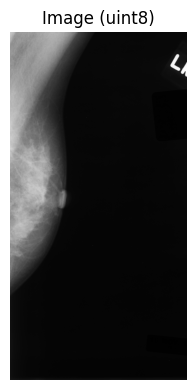

In [11]:
# Assurer uint8 mono-canal à partir de `image` ou réutiliser `img_uint8` existant
try:
    img_uint8
except NameError:
    if np.issubdtype(image.dtype, np.floating):
        img_uint8 = (np.clip(image, 0.0, 1.0) * 255).astype(np.uint8)
    elif image.dtype == np.uint16:
        lo, hi = np.percentile(image, (1, 99.5))
        img_uint8 = ((np.clip(image, lo, hi) - lo) / max(hi - lo, 1e-6) * 255).astype(np.uint8)
    else:
        img_uint8 = image.astype(np.uint8)

# Version float [0,1] pour la suite du pipeline
image_u01 = img_uint8.astype(np.float32) / 255.0

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
ax.set_title('Image (uint8)')
ax.axis('off')
plt.tight_layout(); plt.show()

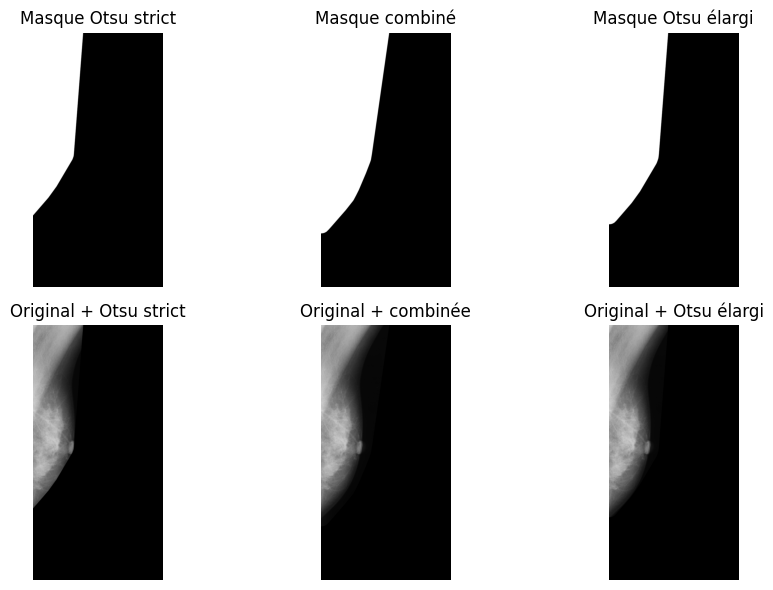

Pixels à 0 (Original uint8): 0.05% | Otsu strict: 78.93% | combiné: 70.19% | Otsu élargi: 73.40%
Otsu=0.3033 | thr_low=0.1213 | thr_scale=0.4


In [12]:
# Parameters and mask logic (imports moved to top consolidated cell)
 # Paramètres
thr_scale = 0.4      # < 1.0 => seuil plus bas qu’Otsu (masque plus large)
min_size = 2000
closing_r = 7
dilation_r = 30
use_convex_hull = True

# Flou pour stabiliser le seuil
# utiliser image float [0,1] calculée plus haut (image_u01 / image)
blur = gaussian(image, sigma=2.0, preserve_range=True)

# Otsu sur les pixels > 0
nz = blur[image > 0]
thr_otsu = threshold_otsu(nz) if nz.size else 0.02
thr_low = max(0.005, thr_otsu * thr_scale, np.percentile(nz, 1) if nz.size else 0.01)

def postprocess(mask, do_dilate=True):
    mask = morphology.remove_small_objects(mask, min_size=min_size)
    mask = binary_fill_holes(mask)
    mask = morphology.binary_closing(mask, morphology.disk(closing_r))
    lab = sk_label(mask, connectivity=1)
    if lab.max() > 0:
        counts = np.bincount(lab.ravel()); counts[0] = 0
        mask = (lab == counts.argmax())
    # Convex hull only if mask contains True values (avoid UserWarning on all-zero)
    if use_convex_hull:
        if mask.any():
            try:
                mask = morphology.convex_hull_image(mask)
            except Exception:
                # ignore failures and keep current mask
                pass
    if do_dilate and dilation_r > 0:
        mask = morphology.binary_dilation(mask, morphology.disk(dilation_r))
    return mask

# 1) Variante stricte (masque d'Otsu exact, sans élargissement)
mask_strict = postprocess(blur > thr_otsu, do_dilate=False)

# 2) Variante combinée (au moins aussi large que l’un des deux)
mask_combined = postprocess((blur > thr_low) | (blur > thr_otsu), do_dilate=True)

# 3) Variante “Otsu élargi” (Otsu + dilatation)
mask_otsu_dil = postprocess(blur > thr_otsu, do_dilate=True)

extra_dilation_r = 50 
if extra_dilation_r and extra_dilation_r > 0:
    try:
        mask_otsu_dil = morphology.binary_dilation(mask_otsu_dil, morphology.disk(int(extra_dilation_r)))
        mask_combined = morphology.binary_dilation(mask_combined, morphology.disk(int(extra_dilation_r)))
    except Exception:
        from scipy.ndimage import binary_dilation
        mask_otsu_dil = binary_dilation(mask_otsu_dil, iterations=int(extra_dilation_r))
        mask_combined = binary_dilation(mask_combined, iterations=int(extra_dilation_r))

def apply_mask(u8img, mask):
    out = u8img.copy()
    out[~mask] = 0
    return out

img_strict = apply_mask(img_uint8, mask_strict)
img_combined = apply_mask(img_uint8, mask_combined)  # use expanded mask for downstream
img_otsu_dil = apply_mask(img_uint8, mask_otsu_dil)

# Visualisation: lignes = [masques, images masquées], colonnes = [stricte, combinée, Otsu élargi]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes[0,0].imshow(mask_strict, cmap='gray');  axes[0,0].set_title("Masque Otsu strict");   axes[0,0].axis('off')
axes[0,1].imshow(mask_combined, cmap='gray');axes[0,1].set_title("Masque combiné");       axes[0,1].axis('off')
axes[0,2].imshow(mask_otsu_dil, cmap='gray');axes[0,2].set_title("Masque Otsu élargi");   axes[0,2].axis('off')

axes[1,0].imshow(img_strict, cmap='gray', vmin=0, vmax=255);  axes[1,0].set_title("Original + Otsu strict");  axes[1,0].axis('off')
axes[1,1].imshow(img_combined, cmap='gray', vmin=0, vmax=255);axes[1,1].set_title("Original + combinée");      axes[1,1].axis('off')
axes[1,2].imshow(img_otsu_dil, cmap='gray', vmin=0, vmax=255);axes[1,2].set_title("Original + Otsu élargi");  axes[1,2].axis('off')
plt.tight_layout(); plt.show()

# Stats
pct0_old = 100.0 * (img_uint8 == 0).mean()
pct0_strict = 100.0 * (img_strict == 0).mean()
pct0_combined = 100.0 * (img_combined == 0).mean()
pct0_otsu_dil = 100.0 * (img_otsu_dil == 0).mean()
print(f"Pixels à 0 (Original uint8): {pct0_old:.2f}% | Otsu strict: {pct0_strict:.2f}% | combiné: {pct0_combined:.2f}% | Otsu élargi: {pct0_otsu_dil:.2f}%")
print(f"Otsu={thr_otsu:.4f} | thr_low={thr_low:.4f} | thr_scale={thr_scale}")

On garde Otsu combiné (à discuter)

Mode estimé: right
Crop window (estimée): (0, 1761, 0, 573) | distance_from_starting_side: 627
Crop window (fixe demandé): (0, 2000, 0, 1152) | distance_from_starting_side: 627
Taille recadrée (avant réduction) : (1152, 2000)
Taille recadrée (après réduction) : (576, 1000)


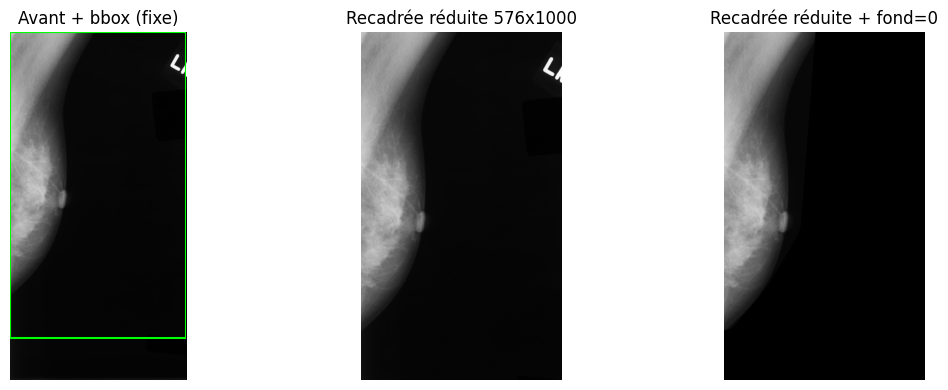

In [13]:
# Appliquer le crop basé sur la plus grande composante de l'image gardée (mask combiné)
def _guess_mode_from_mask(mask: np.ndarray) -> str:
    h, w = mask.shape[:2]
    cols = np.where(mask.any(axis=0))[0]
    if cols.size == 0:
        return 'left'
    left_gap = int(cols[0])
    right_gap = int((w - 1) - cols[-1])
    return 'right' if left_gap <= right_gap else 'left'

mode = _guess_mode_from_mask(mask_otsu_dil.astype(bool))
print('Mode estimé:', mode)

win_loc, rightmost_pts, bottommost_pts, dist_side = crop_img_from_largest_connected(
    img=img_otsu_dil,
    mode=mode,
    erode_dialate=True,
    iterations=20,
    buffer_size=50,
    find_rightmost_from_ratio=1/3
)
y_top, y_bot, x_left, x_right = win_loc
print('Crop window (estimée):', win_loc, '| distance_from_starting_side:', dist_side)

# --- Fixed output size (modifiable) ---
target_h = 2000   # hauteur souhaitée avant downscale
target_w = 1400   # largeur souhaitée avant downscale

H, W = img_uint8.shape[:2]

# centre de la fenêtre calculée
y_c = (y_top + y_bot) // 2
x_c = (x_left + x_right) // 2

# calculer nouvelles bornes centrées, en veillant aux bords
y0 = int(max(0, y_c - target_h // 2))
y1 = int(min(H, y0 + target_h))
if (y1 - y0) < target_h:
    y0 = int(max(0, y1 - target_h))

x0 = int(max(0, x_c - target_w // 2))
x1 = int(min(W, x0 + target_w))
if (x1 - x0) < target_w:
    x0 = int(max(0, x1 - target_w))

# si l'image est plus petite que la taille cible, utiliser l'image entière
if H < target_h:
    y0, y1 = 0, H
if W < target_w:
    x0, x1 = 0, W

new_win_loc = (y0, y1, x0, x1)
print('Crop window (fixe demandé):', new_win_loc, '| distance_from_starting_side:', dist_side)

# Créer des sorties recadrées cohérentes pour la suite du pipeline (taille forcée si possible)
img_kept_cropped = img_uint8[y0:y1, x0:x1]                    # uint8 recadrée
mask_kept_cropped = mask_otsu_dil[y0:y1, x0:x1]      # utiliser masque élargi
image_kept_cropped = image[y0:y1, x0:x1]                      # float[0,1] recadrée

print("Taille recadrée (avant réduction) :", img_kept_cropped.shape[::-1])  # (W, H) affiché

# Optionnel: remettre à zéro le fond en utilisant le masque recadré (safe)
img_kept_cropped_bg0 = img_kept_cropped.copy()
try:
    mm = mask_kept_cropped.astype(bool)
    if mm.shape == img_kept_cropped.shape:
        img_kept_cropped_bg0[~mm] = 0
    else:
        hmin = min(mm.shape[0], img_kept_cropped.shape[0])
        wmin = min(mm.shape[1], img_kept_cropped.shape[1])
        img_kept_cropped_bg0[:hmin, :wmin][~mm[:hmin, :wmin]] = 0
except Exception:
    pass

# --- Downscale final output (divide size by 2 while keeping content) ---
final_scale = 0.5  # 0.5 -> moitié largeur/hauteur ; changer si besoin
if final_scale != 1.0 and img_kept_cropped.size:
    # compute new size (width, height) for cv2.resize
    Hc, Wc = img_kept_cropped.shape[:2]
    new_w = max(1, int(round(Wc * final_scale)))
    new_h = max(1, int(round(Hc * final_scale)))

    # resize uint8 image and bg0 using area interpolation for downscaling
    img_kept_cropped_small = cv2.resize(img_kept_cropped, (new_w, new_h), interpolation=cv2.INTER_AREA)
    img_kept_cropped_bg0_small = cv2.resize(img_kept_cropped_bg0, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # resize mask with nearest to preserve binary nature
    try:
        mask_u8 = (mask_kept_cropped.astype(np.uint8) * 255)
        mask_small_u8 = cv2.resize(mask_u8, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        mask_kept_cropped_small = (mask_small_u8 > 127)
    except Exception:
        mask_kept_cropped_small = None

    # resize float image (image_kept_cropped) with INTER_AREA and keep float range
    try:
        imgf = (image_kept_cropped * 255.0).astype(np.uint8) if image_kept_cropped.dtype != np.uint8 else image_kept_cropped
        imgf_small_u8 = cv2.resize(imgf, (new_w, new_h), interpolation=cv2.INTER_AREA)
        image_kept_cropped_small = imgf_small_u8.astype(np.float32) / 255.0
    except Exception:
        image_kept_cropped_small = None

    print("Taille recadrée (après réduction) :", (new_w, new_h))

else:
    img_kept_cropped_small = img_kept_cropped.copy()
    img_kept_cropped_bg0_small = img_kept_cropped_bg0.copy()
    mask_kept_cropped_small = mask_kept_cropped.copy()
    image_kept_cropped_small = image_kept_cropped.copy()
    print("Aucune réduction appliquée (final_scale=1)")

# Visualisation rapide (affiche la version réduite)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
axes[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               fill=False, edgecolor='lime', linewidth=1.5))
axes[0].set_title('Avant + bbox (fixe)')
axes[0].axis('off')

axes[1].imshow(img_kept_cropped_small, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Recadrée réduite {img_kept_cropped_small.shape[1]}x{img_kept_cropped_small.shape[0]}')
axes[1].axis('off')

axes[2].imshow(img_kept_cropped_bg0_small, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Recadrée réduite + fond=0')
axes[2].axis('off')

plt.tight_layout(); plt.show()

## Entraînement

Normalisation

In [14]:
# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)

# paramètres
pad = 30
target_h, target_w = 2000, 1400
final_scale = 0.5
iterations_erode_dilate = 20
buffer_size = 50
find_rightmost_from_ratio = 1/3

candidates = []
# utiliser variable d'environnement si présente
dataset_root_from_env = os.environ.get('MAMMO_DATA_ROOT')
if dataset_root_from_env:
    candidates.append(dataset_root_from_env)
candidates.append(os.path.join(os.getcwd(), 'archive'))


Preprocessing

In [15]:
dataset_root = None
for c in candidates:
    if c and os.path.isdir(c):
        dataset_root = c
        break
if dataset_root is None:
    raise FileNotFoundError("Racine MINI-DDSM introuvable. Ajuster `candidates`.")

out_root = os.path.join(dataset_root, "processed")
os.makedirs(out_root, exist_ok=True)

all_pngs_raw = glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)
all_pngs = [p for p in all_pngs_raw
            if not os.path.commonpath([p, out_root]) == out_root and 'mask' not in p.lower()]
n_ignored = len(all_pngs_raw) - len(all_pngs)
print(f"Total found: {len(all_pngs_raw)} | Ignored (contain 'mask'): {n_ignored} | Remaining: {len(all_pngs)}")
if not all_pngs:
    raise FileNotFoundError("Aucune .png trouvée sous dataset_root après filtrage.")

out_root = os.path.join(dataset_root, "processed")
os.makedirs(out_root, exist_ok=True)

# quick skip if it looks like everything is already processed
existing_outs = glob.glob(os.path.join(out_root, "**", "*_processed.png"), recursive=True)
if len(existing_outs) >= len(all_pngs) and len(existing_outs) > 0:
    print(f"Tous les fichiers semblent déjà traités ({len(existing_outs)}). Sortie: {out_root}")
else:
    for p in tqdm(all_pngs, desc=f"Processing {len(all_pngs)} images -> img_kept_cropped"):
        # compute output path early so we can skip already saved results
        rel = os.path.relpath(p, dataset_root)
        dst_dir = os.path.join(out_root, os.path.dirname(rel))
        os.makedirs(dst_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(rel))[0]
        out_png = os.path.join(dst_dir, base + "_processed.png")
        if os.path.exists(out_png):
            # already processed -> skip
            continue

        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        # gris
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # crop bord
        try:
            img = crop_borders(img, pad=pad)
        except Exception:
            pass
        
        img_u8 = np.clip(img, 0, 255).astype(np.uint8)
        image_f01 = img_u8.astype(np.float32) / 255.0

        # masque 
        try:
            blur = gaussian(image_f01, sigma=2.0, preserve_range=True)
            nz = blur[image_f01 > 0]
            thr_otsu = threshold_otsu(nz) if nz.size else 0.02
            thr_low = max(0.005, thr_otsu * 0.4, np.percentile(nz, 1) if nz.size else 0.01)
            mask_otsu_dil = postprocess((blur > thr_low) | (blur > thr_otsu), do_dilate=True)
        except Exception:
            # fallback simple threshold
            mask_otsu_dil = image_f01 > 0.01

        # <-- Changement: remplacer par Otsu élargi
        try:
            # recompute strict Otsu then dilate (robuste fallback to ensure mask_otsu_dil existe)
            mask_otsu_dil = postprocess(blur > thr_otsu, do_dilate=True)
        except Exception:
            # si échec, garder l'ancien mask_otsu_dil (déjà défini) - safe fallback
            pass

        # appliquer masque et remettre fond à 0 (sur img_u8)
        img_otsu_dil = apply_mask(img_u8, mask_otsu_dil)
        # estimer mode et crop autour de la plus grosse composante (fonction fournie)
        try:
            mode = _guess_mode_from_mask(mask_otsu_dil.astype(bool))
            win_loc, rightmost_pts, bottommost_pts, dist_side = crop_img_from_largest_connected(
                img=img_otsu_dil, mode=mode,
                erode_dialate=True, iterations=iterations_erode_dilate,
                buffer_size=buffer_size, find_rightmost_from_ratio=find_rightmost_from_ratio
            )
            y_top, y_bot, x_left, x_right = win_loc
        except Exception:
            # fallback : utiliser tout
            H, W = img_u8.shape[:2]
            y_top, y_bot, x_left, x_right = 0, H, 0, W

        # appliquer fenêtre fixe centrée comme dans le notebook
        H, W = img_u8.shape[:2]
        y_c = (y_top + y_bot) // 2
        x_c = (x_left + x_right) // 2
        y0 = int(max(0, y_c - target_h // 2)); y1 = int(min(H, y0 + target_h))
        if (y1 - y0) < target_h: y0 = int(max(0, y1 - target_h))
        x0 = int(max(0, x_c - target_w // 2)); x1 = int(min(W, x0 + target_w))
        if (x1 - x0) < target_w: x0 = int(max(0, x1 - target_w))
        if H < target_h: y0, y1 = 0, H
        if W < target_w: x0, x1 = 0, W

        img_kept_cropped = img_u8[y0:y1, x0:x1]
        mask_kept_cropped = mask_otsu_dil[y0:y1, x0:x1] if mask_otsu_dil is not None else np.ones_like(img_kept_cropped, dtype=bool)

        # remettre fond à 0 selon masque
        img_kept_cropped_bg0 = img_kept_cropped.copy()
        try:
            mm = mask_kept_cropped.astype(bool)
            if mm.shape == img_kept_cropped_bg0.shape:
                img_kept_cropped_bg0[~mm] = 0
            else:
                hmin = min(mm.shape[0], img_kept_cropped_bg0.shape[0])
                wmin = min(mm.shape[1], img_kept_cropped_bg0.shape[1])
                img_kept_cropped_bg0[:hmin, :wmin][~mm[:hmin, :wmin]] = 0
        except Exception:
            pass

        # 7) downscale final (comme img_kept_cropped_bg0_small)
        if final_scale != 1.0 and img_kept_cropped_bg0.size:
            Hc, Wc = img_kept_cropped_bg0.shape[:2]
            new_w = max(1, int(round(Wc * final_scale))); new_h = max(1, int(round(Hc * final_scale)))
            img_out = cv2.resize(img_kept_cropped_bg0, (new_w, new_h), interpolation=cv2.INTER_AREA)
        else:
            img_out = img_kept_cropped_bg0.copy()

        # sauvegarder (préserver arborescence relative)
        cv2.imwrite(out_png, img_out)
        
    print("Traitement terminé. Sortie dans :", out_root)

Total found: 18685 | Ignored (contain 'mask'): 10875 | Remaining: 7810
Tous les fichiers semblent déjà traités (7810). Sortie: C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\processed


Calcul de la moyenne et de l'écart-type avant normalisation

In [16]:
processed_dir = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\processed"
if not os.path.isdir(processed_dir):
    raise FileNotFoundError(f"Répertoire introuvable: {processed_dir!r}")

# lister images sources (png/jpg) — tolérer variations de casse
candidates = glob.glob(os.path.join(processed_dir, "**", "*.png"), recursive=True)
if not candidates:
    all_files = glob.glob(os.path.join(processed_dir, "**", "*.*"), recursive=True)
    candidates = [p for p in all_files if p.lower().endswith((".png", ".jpg", ".jpeg"))]
if not candidates:
    raise FileNotFoundError(f"Aucune image trouvée sous {processed_dir!r}. Relancer le preprocessing ou vérifier le chemin.")

random.seed(42)
N = 2000
all_imgs = sorted(candidates)
batch_paths = all_imgs if len(all_imgs) <= N else random.sample(all_imgs, N)
print(f"Nombre d'images disponibles: {len(all_imgs)} | taille du batch utilisé: {len(batch_paths)}")

mean_arr, std_arr = compute_mean_std(batch_paths)   # retourne en échelle 0-255
mean_val = float(np.atleast_1d(mean_arr)[0])
std_val = float(np.atleast_1d(std_arr)[0])
mean_01 = mean_val / 255.0
std_01 = max(std_val / 255.0, 1e-6)

print(f"Résultat compute_mean_std -> mean={mean_val:.3f}, std={std_val:.3f} (échelle 0-255)")
print(f"En [0,1] -> mean={mean_01:.6f}, std={std_01:.6f}")

assert np.isfinite(mean_val) and np.isfinite(std_val)
assert 0.0 <= mean_val <= 255.0
assert std_val >= 0.0

# sauvegarder stats pour réutilisation rapide
stats_path = os.path.join(processed_dir, "norm_stats.json")
with open(stats_path, "w", encoding="utf-8") as f:
    json.dump({"mean_val": mean_val, "std_val": std_val, "mean_01": mean_01, "std_01": std_01}, f, indent=2)
print("Stats sauvegardées dans:", stats_path)

Nombre d'images disponibles: 7810 | taille du batch utilisé: 2000


100%|██████████| 2000/2000 [00:07<00:00, 251.85it/s]

Résultat compute_mean_std -> mean=198.526, std=104.226 (échelle 0-255)
En [0,1] -> mean=0.778533, std=0.408729
Stats sauvegardées dans: C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\processed\norm_stats.json


Normalisation

In [17]:
# Vérifier et créer les fichiers *_norm.npy manquants (normalisation simple: (img - mean)/std)
def expected_norm_path(img_path):
    base, _ = os.path.splitext(img_path)
    return base + "_norm.npy"

# lister images et norms existants
imgs = sorted([p for p in glob.glob(os.path.join(processed_dir, "**", "*.*"), recursive=True)
               if p.lower().endswith((".png", ".jpg", ".jpeg"))])
norms = set(glob.glob(os.path.join(processed_dir, "**", "*_norm.npy"), recursive=True))

missing = [p for p in imgs if expected_norm_path(p) not in norms]
print(f"Images totales trouvées: {len(imgs)}")
print(f"Normaux existants: {len(norms)}")
print(f"Manquants à créer: {len(missing)}")
if len(missing) <= 10:
    for p in missing[:50]:
        print(" missing:", p)

# si mean/std non présents en mémoire, recharger depuis fichier
try:
    mv = mean_val; sv = std_val
except NameError:
    with open(stats_path, "r", encoding="utf-8") as f:
        st = json.load(f)
    mv = float(st["mean_val"]); sv = float(st["std_val"])

if sv <= 0 or not np.isfinite(mv) or not np.isfinite(sv):
    raise ValueError(f"mean/std invalides: mean={mv}, std={sv}")

# boucle de création (non bloquante sur erreurs)
if missing:
    for img_path in tqdm(missing, desc="Création _norm.npy"):
        try:
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            img = img.astype(np.float32)
            # si image couleur, convertir en gris en moyenne des canaux
            if img.ndim == 3:
                img_gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)
            else:
                img_gray = img
            img_norm = (img_gray - mv) / max(sv, 1e-6)
            np.save(expected_norm_path(img_path), img_norm)
        except Exception:
            # ignorer fichier problématique
            continue
    print("Normalisation terminée pour les fichiers manquants.")
else:
    print("Aucun fichier manquant. Tout est déjà normalisé.")

Images totales trouvées: 7810
Normaux existants: 7810
Manquants à créer: 0
Aucun fichier manquant. Tout est déjà normalisé.


In [58]:
# Vérification globale sur les *_norm.npy existants (moyenne globale attendue ~0, std ~1)
norm_candidates = glob.glob(os.path.join(processed_dir, "**", "*_norm.npy"), recursive=True)
if not norm_candidates:
    raise FileNotFoundError(f"Aucune image normalisée trouvée sous {processed_dir!r}. Relancer le preprocessing ou vérifier le chemin.")

accum_sum = 0.0
accum_sumsq = 0.0
n_pixels = 0
for norm_path in tqdm(norm_candidates, desc="Aggregation norms"):
    arr = np.load(norm_path).astype(np.float64)
    accum_sum += arr.sum()
    accum_sumsq += (arr ** 2).sum()
    n_pixels += arr.size

mean_norm = accum_sum / n_pixels
std_norm = float(np.sqrt(max(0.0, accum_sumsq / n_pixels - mean_norm ** 2)))
print(f"Moyenne après normalisation : {mean_norm:.6f}")
print(f"Écart-type après normalisation : {std_norm:.6f}")

Aggregation norms: 100%|██████████| 7810/7810 [01:19<00:00, 98.34it/s] 

Moyenne après normalisation : 0.027394
Écart-type après normalisation : 0.979353


Split

In [18]:
def load_split_lists(splits_dir, processed_dir_override=None, seed=42,
                     train_frac=0.70, val_frac=0.15, test_frac=0.15, pattern="*_norm.npy"):
    random.seed(seed); np.random.seed(seed); rnd = random.Random(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

    os.makedirs(splits_dir, exist_ok=True)
    train_txt = os.path.join(splits_dir, "train.txt")
    val_txt = os.path.join(splits_dir, "val.txt")
    test_txt = os.path.join(splits_dir, "test.txt")
    if all(os.path.exists(p) for p in (train_txt, val_txt, test_txt)):
        def read_lines(p):
            with open(p, "r", encoding="utf-8") as f:
                return [l.strip() for l in f if l.strip()]
        return read_lines(train_txt), read_lines(val_txt), read_lines(test_txt)

    search_root = processed_dir_override or processed_dir
    norm_candidates = glob.glob(os.path.join(search_root, "**", pattern), recursive=True)
    # fallback: accept processed PNGs if no .npy present
    if not norm_candidates:
        pngs = glob.glob(os.path.join(search_root, "**", "*_processed.png"), recursive=True)
        norm_candidates = pngs

    if not norm_candidates:
        raise FileNotFoundError(f"Aucune image normalisée trouvée sous {search_root!r} (pattern={pattern}).")

    norm_candidates = sorted(norm_candidates)
    N = len(norm_candidates)
    n_train = int(N * train_frac)
    n_val = int(N * val_frac)
    n_test = N - n_train - n_val

    shuffled = norm_candidates.copy()
    rnd.shuffle(shuffled)
    train_list = shuffled[:n_train]
    val_list = shuffled[n_train:n_train + n_val]
    test_list = shuffled[n_train + n_val:]

    for name, lst in (("train", train_list), ("val", val_list), ("test", test_list)):
        out_txt = os.path.join(splits_dir, f"{name}.txt")
        with open(out_txt, "w", encoding="utf-8") as f:
            for p in lst:
                f.write(p + "\n")

    meta = {"total": N, "train": len(train_list), "val": len(val_list), "test": len(test_list), "seed": seed}
    with open(os.path.join(splits_dir, "splits_info.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    print(f"Split saved in: {splits_dir}")
    print(f"(total={N}, train={len(train_list)}, val={len(val_list)}, test={len(test_list)})")
    return train_list, val_list, test_list

splits_dir = os.path.join(processed_dir, "splits")
train_paths, val_paths, test_paths = load_split_lists(splits_dir, processed_dir_override=processed_dir, seed=42)
train_paths = [p for p in train_paths if p.endswith("_norm.npy")]
val_paths   = [p for p in val_paths if p.endswith("_norm.npy")]
test_paths  = [p for p in test_paths if p.endswith("_norm.npy")]
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train: 5467 | Val: 1171 | Test: 1172


In [ ]:
# # Préparer les transforms et DataLoaders (assurer mean/std en échelle [0,1] pour torchvision.Normalize)
# mean_norm = mean_01 if 'mean_01' in globals() else (mv / 255.0)
# std_norm = std_01 if 'std_01' in globals() else (sv / 255.0)

# from torchvision import transforms as T
# default_transforms = T.Compose([
#     T.Resize((img_size[1], img_size[0])),   # (H, W) = (1000, 700)
#     T.ToTensor(),                           # -> float [0,1]
#     T.Normalize(mean=[mean_norm], std=[std_norm])
# ])
# print("default_transforms using mean/std (in [0,1]):", mean_norm, std_norm)

# # Dataset / DataLoader setup (adapt as dans le notebook)
# train_ds = MammogramPNGDataset(train_paths, transform=default_transforms, apply_transform_to_npy=False)
# val_ds = MammogramPNGDataset(val_paths, transform=default_transforms, apply_transform_to_npy=False)
# test_ds = MammogramPNGDataset(test_paths, transform=default_transforms, apply_transform_to_npy=False)

# batch_size = 32
# num_workers = 4 if os.name != "nt" else 0
# pin_memory = True if torch.cuda.is_available() else False

# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
# val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
# test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

# print("DataLoaders ready. Example batches (train/val):", len(train_ds), len(val_ds))

In [19]:
def label_from_path(p):
    lc = p.lower()
    if "normal" in lc:
        return 0
    if "benign" in lc:
        return 1
    if "cancer" in lc:
        return 2
    parent = os.path.basename(os.path.dirname(p)).lower()
    if "normal" in parent: return 0
    if "benign" in parent: return 1
    if "cancer" in parent: return 2
    raise ValueError(f"Impossible d'inférer le label depuis le chemin: {p}")

img_size = (700, 1000) 
# default_transforms = transforms.Compose([
#     transforms.Resize(img_size),    # resize à 700x1000
#     transforms.ToTensor(),          # tensor [1,H,W] pour grayscale
#     transforms.Normalize(mean=[mean_norm], std=[std_norm])  # centrage simple (j'ai changé mean_01 par mean_norm)
# ])

default_transforms = transforms.Compose([
    transforms.ToTensor(),      
    transforms.Resize((1000,700)),  
])


In [20]:
class MammogramPNGDataset(Dataset):
    def __init__(self, paths, transform=None, apply_transform_to_npy=False):
        """
        paths: list of image paths (png/jpg) or normalized .npy files.
        apply_transform_to_npy: if True will attempt to call self.transform on loaded tensors;
                                default False because .npy are pre-normalized in this project.
        """
        self.paths = list(paths)
        self.transform = transform or default_transforms
        self.apply_transform_to_npy = apply_transform_to_npy

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        if p.lower().endswith(".npy"):
            arr = np.load(p).astype(np.float32)
            # normalize to CHW
            if arr.ndim == 2:
                arr = np.expand_dims(arr, 0)           # -> (1, H, W)
            elif arr.ndim == 3:
                # If HWC with channel last (common), convert to CHW
                if arr.shape[-1] in (1, 3):
                    arr = np.transpose(arr, (2, 0, 1))
                # else assume already CHW
            x = torch.from_numpy(arr).float()  # CHW

            # Ensure channel dim exists
            if x.dim() == 2:
                x = x.unsqueeze(0)

            # Resize / pad to target size so batches can be collated
            try:
                # `img_size` défini plus haut : (width, height) dans ce notebook
                target_h, target_w = img_size[1], img_size[0]
            except Exception:
                target_h, target_w = 1000, 700

            import torch.nn.functional as F
            # add batch dim for interpolate: (1, C, H, W)
            x = x.unsqueeze(0)
            # interpolate supports floating tensors; preserve single channel
            x = F.interpolate(x, size=(target_h, target_w), mode='bilinear', align_corners=False)
            x = x.squeeze(0)  # back to (C, H, W)

            # Option: apply transform if user requested (careful: default_transforms expects PIL)
            if self.apply_transform_to_npy and callable(self.transform):
                try:
                    x = self.transform(x)
                except Exception:
                    pass
        else:
            # regular image files -> use PIL + torchvision transforms
            img = Image.open(p).convert("L")
            if self.transform is not None:
                x = self.transform(img)
            else:
                x = transforms.ToTensor()(img)

        y = label_from_path(p)
        return x, int(y)

In [21]:
seed=42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [22]:
batch_size = 32
num_workers = 4 if os.name != "nt" else 0

train_ds = MammogramPNGDataset(train_paths, transform=default_transforms, apply_transform_to_npy=False)
val_ds = MammogramPNGDataset(val_paths, transform=default_transforms, apply_transform_to_npy=False)
test_ds = MammogramPNGDataset(test_paths, transform=default_transforms, apply_transform_to_npy=False)

# pin_memory only when using CUDA
pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=pin_memory)

In [23]:
device = torch.device("cuda")
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0)) #c'est censé être RTX

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


Distribution des labels dans les datasets

Train: total=5467
  0 (normal): 1700 (31.10%)
  1 (benign): 1879 (34.37%)
  2 (cancer): 1888 (34.53%)
Val: total=1171
  0 (normal): 345 (29.46%)
  1 (benign): 388 (33.13%)
  2 (cancer): 438 (37.40%)
Test: total=1172
  0 (normal): 363 (30.97%)
  1 (benign): 418 (35.67%)
  2 (cancer): 391 (33.36%)


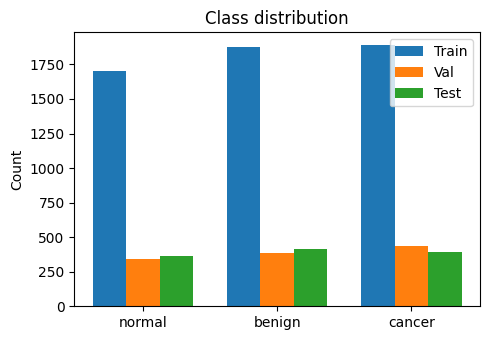

In [24]:
class_names = {0: "normal", 1: "benign", 2: "cancer"}

def balance_report(paths, name):
    cnt = Counter()
    for p in paths:
        try:
            lbl = label_from_path(p)
        except Exception:
            lbl = None
        cnt[lbl] += 1
    total = len(paths)
    print(f"{name}: total={total}")
    for k in sorted(class_names.keys()):
        c = cnt.get(k, 0)
        print(f"  {k} ({class_names[k]}): {c} ({100.0 * c / max(1, total):.2f}%)")
    return cnt

# calculer rapports
cnt_train = balance_report(train_paths, "Train")
cnt_val   = balance_report(val_paths,   "Val")
cnt_test  = balance_report(test_paths,  "Test")

# plot grouped bar chart
labels = [class_names[i] for i in range(3)]
x = np.arange(len(labels))
width = 0.25
train_counts = [cnt_train.get(i, 0) for i in range(3)]
val_counts   = [cnt_val.get(i, 0) for i in range(3)]
test_counts  = [cnt_test.get(i, 0) for i in range(3)]

fig, ax = plt.subplots(figsize=(5,3.5))
ax.bar(x - width, train_counts, width, label='Train')
ax.bar(x,         val_counts,   width, label='Val')
ax.bar(x + width, test_counts,  width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title("Class distribution")
ax.legend()
plt.tight_layout()
plt.show()

Chargement du ResNet

In [25]:
try:
    model = models.resnet18(weights="IMAGENET1K_V1")
except Exception:
    model = models.resnet18(pretrained=True)

# Adapter la première couche (RGB->1 channel)
w = model.conv1.weight.data.clone()  # shape (out, in, k, k)
in_ch_new = 1
model.conv1 = nn.Conv2d(in_ch_new,
                        model.conv1.out_channels,
                        kernel_size=model.conv1.kernel_size,
                        stride=model.conv1.stride,
                        padding=model.conv1.padding,
                        bias=(model.conv1.bias is not None))
# initialiser par la moyenne des canaux RGB -> canal unique
with torch.no_grad():
    model.conv1.weight.data = w.mean(dim=1, keepdim=True)

# Adapter la tête pour 3 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)

# envoyer sur device
model = model.to(device)
print("Model ready on", device)

Model ready on cuda


- soit un pb dans le calcul de la val loss, 
- soit il y a des inf pour les logit (à check)
- je dois vérifier à la main sur des batchs ce qu'il se passe dans le jeu de validation (je dois calculer la val loss sur certains batch et essayer de comprendre pk)
- essayer de calculer moyenne et écart-type de train et val ou alors charger une image de train et de val pour voir => faire en premier
ça a l'air d'être une erreur de preprocessing

- sauvegarder les checkpoints ailleurs du MCDropout (mettre un autre chemin sur l'ordi en dehors du repo)

Boucle d'entraînement

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

try:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     factor=0.5, patience=3, verbose=True)
except TypeError:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     factor=0.5, patience=3)

save_dir = r"C:\Users\Invite\Documents\safe"
os.makedirs(save_dir, exist_ok=True)

# charger checkpoint pour reprendre l'entraînement si disponible
ckpt_path = os.path.join(save_dir, "epoch_010.pth")
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if ckpt.get("scheduler_state_dict") is not None and 'scheduler' in locals():
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    for pg in optimizer.param_groups:
        pg['lr'] = ckpt.get("lr", pg.get('lr', pg['lr']))
    start_epoch = ckpt.get("epoch", 0) + 1
    best_val_loss = ckpt.get("val_loss", float('inf'))
    print(f"Checkpoint chargé : {ckpt_path} -> reprise à epoch {start_epoch}, best_val_loss={best_val_loss:.4f}")
else:
    start_epoch = 1
    best_val_loss = float('inf')
    print("Aucun checkpoint trouvé, entraînement à partir de zéro.")

# Training loop parameters
num_epochs = 50
losses = {'train': [], 'val': []}

# JSON file to save losses dynamically
losses_json = os.path.join(save_dir, "losses_log.json")

# Early stopping
es_patience = 7
es_min_delta = 1e-4
es_wait = 0

start_time = time.time()
for epoch in range(1, num_epochs + 1):
    model.train()
    running = 0.0
    n_steps = 0
    p = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - train", leave=False)
    for imgs, labels in p:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running += loss.item()
        n_steps += 1
        p.set_postfix(train_loss=running / n_steps)

    epoch_train_loss = running / max(1, n_steps)
    losses['train'].append(epoch_train_loss)

    # Validation
    model.eval()
    val_running = 0.0
    val_steps = 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - val", leave=False):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, dtype=torch.long, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_running += loss.item()
            val_steps += 1

    epoch_val_loss = val_running / max(1, val_steps)
    losses['val'].append(epoch_val_loss)

    # Scheduler step
    try:
        scheduler.step(epoch_val_loss)
    except Exception:
        pass

    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6g} | Elapsed: {elapsed/60:.2f} min")

    # Save checkpoint for this epoch (epoch_###.pth) + update last_model.pth
    state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if 'scheduler' in locals() else None,
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "lr": current_lr
    }
    epoch_ckpt = os.path.join(save_dir, f"epoch_{epoch:03d}.pth")
    last_ckpt = os.path.join(save_dir, "last_model.pth")
    torch.save(state, epoch_ckpt)
    torch.save(state, last_ckpt)

    # Update JSON file for live plotting
    with open(losses_json, "w") as f:
        json.dump(losses, f)

    # Checkpoint best
    if epoch_val_loss + es_min_delta < best_val_loss:
        best_val_loss = epoch_val_loss
        es_wait = 0
        best_ckpt = os.path.join(save_dir, "best_model.pth")
        torch.save(state, best_ckpt)
        print(f"  -> New best val loss. Checkpoint saved to {best_ckpt}")
    else:
        es_wait += 1
        print(f"  -> No improvement ({es_wait}/{es_patience})")

    # Early stopping
    if es_wait >= es_patience:
        print(f"Early stopping triggered after {es_wait} epochs without improvement.")
        break

# Plot losses
try:
    plt.figure(figsize=(6,4))
    plt.plot(losses['train'], label='Train Loss')
    plt.plot(losses['val'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception as e:
    print("Plot failed:", e)


Checkpoint chargé : C:\Users\Invite\Documents\safe\epoch_010.pth -> reprise à epoch 11, best_val_loss=0.9782


KeyboardInterrupt: 

Accuracy pour 3 classes

In [36]:
def compute_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


In [37]:
best_ckpt = torch.load(os.path.join(save_dir, "best_model.pth"), map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

acc_val   = compute_accuracy(model, val_loader, device)

print(f"Val Accuracy:   {acc_val:.4f}")


100%|██████████| 37/37 [02:11<00:00,  3.54s/it]

Val Accuracy:   0.5961


Accuracy pour 2 classes

In [ ]:
# import pandas as pd

# def make_binary_balanced_df(paths):
#     """
#     Crée un DataFrame avec colonnes:
#     - 'path': chemin vers l'image
#     - 'label': binaire 0/1 (0 = normal/benign, 1 = cancer)
#     Équilibre le dataset en sous-échantillonnant les 0 pour avoir autant de 1 que de 0.
#     """
#     data = []
#     for p in paths:
#         y_orig = label_from_path(p)
#         y_bin = 0 if y_orig in (0,1) else 1
#         data.append({'path': p, 'label': y_bin})

#     df = pd.DataFrame(data)

#     # Séparer classes
#     df_0 = df[df['label'] == 0]
#     df_1 = df[df['label'] == 1]

#     n1 = len(df_1)
#     n0 = len(df_0)

#     # Sous-échantillonner la classe 0 si elle est plus grande
#     if n0 > n1:
#         df_0 = df_0.sample(n1, random_state=42)

#     df_balanced = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)
#     return df_balanced

In [38]:
class BinaryMammoDatasetFromDF(Dataset):
    def __init__(self, df, transform=None):
        """
        df: DataFrame avec colonnes 'path' et 'label'
        transform: torchvision transforms à appliquer (pour PIL images)
        Cette version supporte aussi les .npy (chargés avec numpy et redimensionnés).
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform or default_transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        p = row['path']
        y = int(row['label'])

        # .npy normalisés -> charger en numpy puis convertir en tensor CHW
        if p.lower().endswith('.npy'):
            arr = np.load(p).astype(np.float32)
            if arr.ndim == 2:
                arr = np.expand_dims(arr, 0)  # -> (1, H, W)
            elif arr.ndim == 3:
                # si HWC -> CHW
                if arr.shape[-1] in (1, 3):
                    arr = np.transpose(arr, (2, 0, 1))
            x = torch.from_numpy(arr).float()  # CHW

            # garantir channel dim
            if x.dim() == 2:
                x = x.unsqueeze(0)

            # redimensionner comme dans MammogramPNGDataset
            try:
                target_h, target_w = img_size[1], img_size[0]
            except Exception:
                target_h, target_w = 1000, 700
            import torch.nn.functional as F
            x = x.unsqueeze(0)  # (1, C, H, W)
            x = F.interpolate(x, size=(target_h, target_w), mode='bilinear', align_corners=False)
            x = x.squeeze(0)    # (C, H, W)
        else:
            # image classique -> PIL + transforms
            img = Image.open(p).convert("L")
            if self.transform:
                x = self.transform(img)
            else:
                x = transforms.ToTensor()(img)

        return x, y


In [40]:
def create_binary_loaders(train_paths, val_paths, test_paths, batch_size=32, num_workers=4, pin_memory=True, transform=None):
    """
    Crée des DataLoaders binaires équilibrés à partir des listes de chemins existantes.
    - normal + benign -> 0
    - cancer -> 1
    - équilibre train et val en sous-échantillonnant les 0
    - test non équilibré
    """
    import pandas as pd

    def make_df(paths, balance=False):
        data = []
        for p in paths:
            y_orig = label_from_path(p)
            y_bin = 0 if y_orig in (0,1) else 1
            data.append({'path': p, 'label': y_bin})
        df = pd.DataFrame(data)
        if balance:
            df_0 = df[df['label']==0]
            df_1 = df[df['label']==1]
            n = min(len(df_0), len(df_1))
            df_0 = df_0.sample(n, random_state=42)
            df_1 = df_1.sample(n, random_state=42)
            df = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)
        return df

    train_df = make_df(train_paths, balance=True)
    val_df   = make_df(val_paths,   balance=True)
    test_df  = make_df(test_paths,  balance=False)

    train_ds = BinaryMammoDatasetFromDF(train_df, transform=transform)
    val_ds   = BinaryMammoDatasetFromDF(val_df, transform=transform)
    test_ds  = BinaryMammoDatasetFromDF(test_df, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader

train_loader_bin, val_loader_bin, test_loader_bin = create_binary_loaders(
    train_paths, val_paths, test_paths,
    batch_size=32,
    num_workers=num_workers,
    pin_memory=pin_memory,
    transform=default_transforms
)

In [ ]:
# train_df_bin = make_binary_balanced_df(train_paths)
# val_df_bin   = make_binary_balanced_df(val_paths)  # si tu veux val équilibré
# test_df_bin  = pd.DataFrame({'path': test_paths, 
#                              'label': [0 if label_from_path(p) in (0,1) else 1 for p in test_paths]})

# train_ds_bin = BinaryMammoDatasetFromDF(train_df_bin, transform=default_transforms)
# val_ds_bin   = BinaryMammoDatasetFromDF(val_df_bin, transform=default_transforms)
# test_ds_bin  = BinaryMammoDatasetFromDF(test_df_bin, transform=default_transforms)

# train_loader_bin = DataLoader(train_ds_bin, batch_size=batch_size, shuffle=True,
#                               num_workers=num_workers, pin_memory=pin_memory)
# val_loader_bin   = DataLoader(val_ds_bin, batch_size=batch_size, shuffle=False,
#                               num_workers=num_workers, pin_memory=pin_memory)
# test_loader_bin  = DataLoader(test_ds_bin, batch_size=batch_size, shuffle=False,
#                               num_workers=num_workers, pin_memory=pin_memory)


In [41]:
best_ckpt = torch.load(os.path.join(save_dir, "best_model.pth"), map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

acc_val_bin = compute_accuracy(model, val_loader_bin, device)
print("Binary val accuracy:", acc_val_bin)


100%|██████████| 28/28 [01:25<00:00,  3.06s/it]

Binary val accuracy: 0.3150684931506849


In [42]:
def compute_binary_accuracy(model, dataloader, device):
    """
    Calcule l'accuracy binaire à partir d'un DataLoader existant.
    - normal + benign -> 0
    - cancer -> 1
    - fonctionne avec des .npy ou des images classiques
    - ne stocke pas tout le dataset sur GPU
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            # Convertir labels en binaire
            labels_bin = torch.tensor([0 if y.item() in (0, 1) else 1 for y in labels], device=device)
            imgs = imgs.to(device)

            logits = model(imgs)
            preds = logits.argmax(1)

            correct += (preds == labels_bin).sum().item()
            total += labels_bin.size(0)

    return correct / total


In [43]:
acc_val_bin = compute_binary_accuracy(model, val_loader, device)

print(f"Binary Val Accuracy:   {acc_val_bin:.4f}")


100%|██████████| 37/37 [01:55<00:00,  3.11s/it]

Binary Val Accuracy:   0.3219


Mini contrôles:
- Tu utilisés bien cuda?
- tes classes sont équilibrées pour l'entraînement et la validation à chaque epoch?
- Tu as mis une stratégie pour l'évolution du learning rate?
- la taille de batch ne fait pas planter la ram?

Donc l'idéal ça serait d'estimer le gradient de la loss par rapport à tous les paramètres avec l'ensemble du dataset 

Et en fait pour des simples raisons de ram on se contente de calculer à chaque step de l'optimizer les gradients seulement par rapport à des mini ensembles de paramètres (en "dégelant progressivement" et en faisant des trucs beaucoup plus sioux cf la doc pytorch d'Adam) et en plus ces plus petits gradients sont estimés seulement sur le batch tiré ! 